# DW-NOMINATE — what the Voteview data actually is

Voteview publishes three levels, and it is easy to reach for the wrong one:

| file | one row is | size |
| --- | --- | --- |
| `votes` | one member's vote on one roll call | 701 MB |
| `rollcalls` | one roll call — date, question, result | 29.8 MB |
| `members` | **one member in one Congress, as a point in ideology space** | 6.2 MB |

`members` is not a voting record. It is what you get after scaling every
individual vote: each member collapses to a coordinate whose geometry predicts
how they voted. That scaling is the hard part and Voteview has done it, which
is why the 6 MB file is the one worth building on.

This notebook is about reading that coordinate — what it means, and what
reductions of it are worth storing as series.

In [1]:
import sys
sys.path.append("../")     # notebooks/<source>/ helpers
sys.path.append("../../")  # repo root

import csv, collections, statistics
import numpy
from matplotlib import pyplot

from lib import config
from utils import fetch, voteview_series as vs

pyplot.style.use(config.glyfish_style)

# The reductions below come from utils/voteview_series.py -- the same code that
# builds the stored series -- so this notebook cannot drift from what is served.
# The raw member rows stay, because the distribution plots need per-member dim1
# and the panel is only medians.
members = [r for r in csv.DictReader(open("data/HSall_members.csv"))
           if r["chamber"] in fetch.CHAMBERS and r["nominate_dim1"]]
scores = vs.load_panel()

PARTY_NAME = {int(float(r["party_code"])): r["party_name"]
              for r in csv.DictReader(open("data/HSall_parties.csv"))}
BINS = numpy.arange(-1, 1.05, 0.06)

print(f"{len(members):,} member-Congress rows, "
      f"{len({c for c, _, _ in scores}):,} Congresses, "
      f"{len(PARTY_NAME)} named parties")

50,728 member-Congress rows, 119 Congresses, 53 named parties


## One row

The scores and the fit diagnostics sit side by side, which is the useful part:
you can see how well the point describes the member rather than taking it on
faith.

In [2]:
# every column, in file order, with what it holds
FIELDS = {
    "congress":     "which Congress: 1 = 1789-91 ... 119 = 2025-27",
    "chamber":      "House, Senate, or President (129 rows -- presidents are scored too)",
    "icpsr":        "ICPSR member id; stable across Congresses, so it tracks a career",
    "state_icpsr":  "ICPSR state code (57 values: states, DC, territories, USA)",
    "district_code": "House district; 0 for the Senate and for at-large seats",
    "state_abbrev": "postal code; 'USA' on President rows",
    "party_code":   "ICPSR party: 100 Democrat, 200 Republican, 56 values in all",
    "occupancy":    "which holder of this seat within the Congress -- 0 sole, else 1,2,... in turn",
    "last_means":   "ICPSR code for how the member last attained office (blank in 54 Congresses)",
    "bioname":      "LAST, First",
    "bioguide_id":  "Library of Congress id -- the join key to congress.gov",
    "born":         "birth year",
    "died":         "death year; blank for the living",
    "nominate_dim1": "THE score: economic left/right, about -1 to +1",
    "nominate_dim2": "secondary axis -- historically race and civil rights",
    "nominate_log_likelihood": "fit of the scaling for this member",
    "nominate_geo_mean_probability": "mean probability the model gives their actual votes; 1.0 is perfect",
    "nominate_number_of_votes": "votes the estimate was built from",
    "nominate_number_of_errors": "of those, how many the model mispredicts",
    "conditional":  "empty in all 51,064 rows -- vestigial, ignore it",
    "nokken_poole_dim1": "alternative scaling: re-estimated each Congress (see below)",
    "nokken_poole_dim2": "the same, second dimension",
}

row = next(r for r in members if r["bioname"].startswith("PELOSI") and r["congress"] == "100")
width = max(len(k) for k in FIELDS)
for key, description in FIELDS.items():
    print(f"  {key:<{width}}  {row[key] or '(blank)':<10}  {description}")

assert set(FIELDS) == set(row), "the file grew a column"      # catches a schema change

  congress                       100         which Congress: 1 = 1789-91 ... 119 = 2025-27
  chamber                        House       House, Senate, or President (129 rows -- presidents are scored too)
  icpsr                          15448       ICPSR member id; stable across Congresses, so it tracks a career
  state_icpsr                    71          ICPSR state code (57 values: states, DC, territories, USA)
  district_code                  5           House district; 0 for the Senate and for at-large seats
  state_abbrev                   CA          postal code; 'USA' on President rows
  party_code                     100         ICPSR party: 100 Democrat, 200 Republican, 56 values in all
  occupancy                      2           which holder of this seat within the Congress -- 0 sole, else 1,2,... in turn
  last_means                     2           ICPSR code for how the member last attained office (blank in 54 Congresses)
  bioname                        PELOSI, Nancy  LA

Four groups: **who** (`congress` … `bioname`), **the estimate** (`nominate_dim1`,
`dim2`), **how good it is** (the four diagnostics), and **the alternative
scaling** (`nokken_poole_*`).

The diagnostics are why the score is worth trusting rather than taking on
faith: 609 votes went into placing her, the model mispredicts 26 of them, and
it assigns her actual votes a mean probability of 0.897. Members with too few
votes to place are the 224 rows with a blank `nominate_dim1`.

Two columns deserve a warning. **`party_code` is written `"200"` in most
Congresses and `"200.0"` in 115–117** — comparing the raw string silently
drops three modern Congresses, so everything here goes through
`fetch.party_code()`. And **`conditional` is blank in every one of the 51,064
rows**; it is a column the format carries and the data never fills.

`nokken_poole_dim1` is the alternative scaling. DW-NOMINATE constrains a member
to drift linearly across their whole career; Nokken–Poole re-estimates them
independently each Congress. Use `nominate_dim1` unless you specifically want
within-career movement.

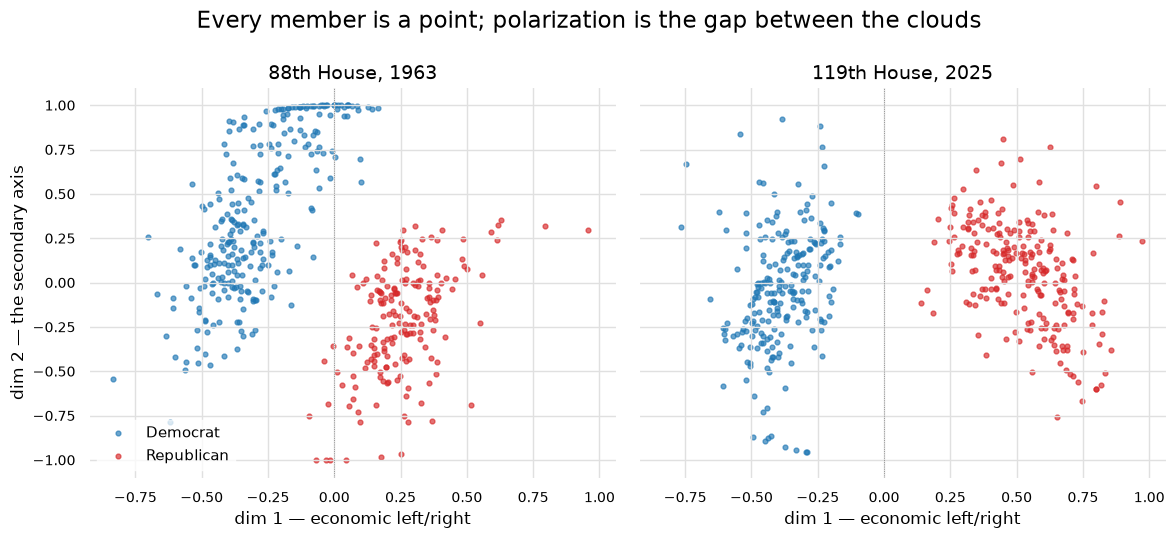

In [3]:
def chamber_rows(congress, chamber="House"):
    return [r for r in members
            if int(r["congress"]) == congress and r["chamber"] == chamber
            and r["nominate_dim2"]]

COLOR = {fetch.DEMOCRAT: "tab:blue", fetch.REPUBLICAN: "tab:red"}

fig, axes = pyplot.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, congress in zip(axes, (88, 119)):
    for code_, label in ((fetch.DEMOCRAT, "Democrat"), (fetch.REPUBLICAN, "Republican")):
        pts = [(float(r["nominate_dim1"]), float(r["nominate_dim2"]))
               for r in chamber_rows(congress) if fetch.party_code(r) == code_]
        ax.scatter(*zip(*pts), s=12, alpha=0.65, color=COLOR[code_], label=label)
    ax.axvline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"{congress}th House, {1789 + (congress - 1) * 2}")
    ax.set_xlabel("dim 1 — economic left/right")
axes[0].set_ylabel("dim 2 — the secondary axis")
axes[0].legend(loc="lower left")
fig.suptitle("Every member is a point; polarization is the gap between the clouds")
fig.tight_layout()

Two things to read off that pair.

**The horizontal gap opens.** In 1963 the clouds nearly touch at zero; by 2025
there is clear space between them, and no member sits in it.

**The vertical spread collapses.** In 1963 the Democrats smear upward to +1.0
— that is the Southern/Northern split on civil rights, which is what `dim2`
was measuring. By 2025 the second dimension has largely stopped carrying
information, which is why almost all modern work uses `dim1` alone.

## The distribution, across three eras

The same fact as a histogram, over the whole two-party span. Third parties are
drawn in grey so each panel accounts for the entire chamber — in the 1850s and
60s they are a real share of it.

Each row shares a y-axis so the panels within an era are comparable; the rows
do not, because the chamber changes size.

### What `dim2` is measuring

It is tempting to read the second dimension as a second flavour of
liberal–conservative. It is not. In 1963 it separates Southern Democrats from
the rest of their own party far more sharply than `dim1` does — and the
Southern bloc was the *conservative* side of that split, on civil rights.

### Before there were two parties

The measures below need a Democrat and a Republican, and for the first third of
the record there is no such pair. The **Era of Good Feelings** — conventionally
1817–1825 — is the extreme case: the Federalists collapse and one party holds
four fifths of the House. There is no gap to measure because there is no second
party to measure it against.

What follows is not a gentle drift into two-party politics. In 1825 the chamber
splits Adams 112 / Jackson 112 — dead even, and bitterly so. Low conflict did
not fade; it broke.

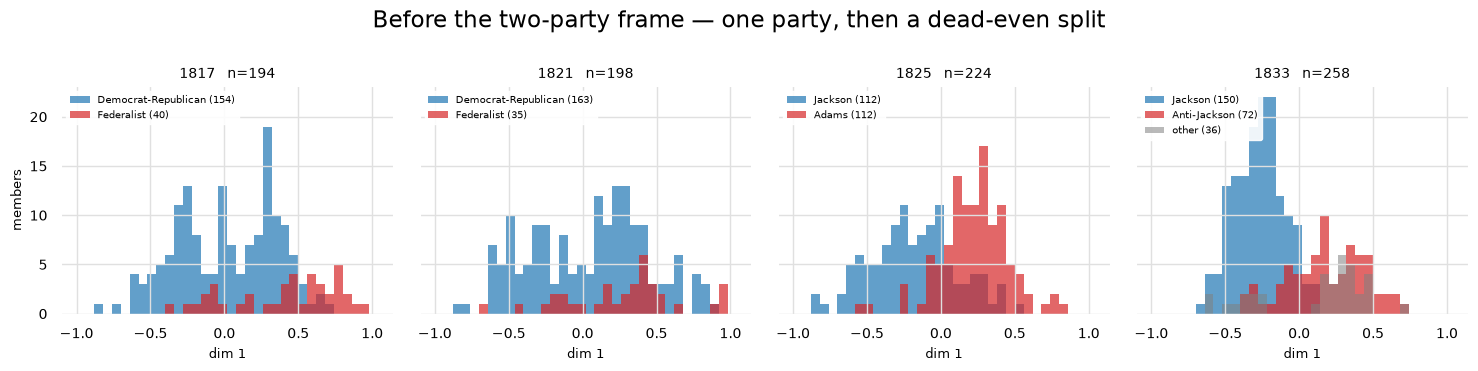

In [4]:
fig, axes = pyplot.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, congress in zip(axes, (15, 17, 19, 23)):
    groups = sorted(((p, v) for (c, ch, p), v in scores.items()
                     if c == congress and ch == "House"),
                    key=lambda kv: -len(kv[1]))
    total = sum(len(v) for _, v in groups)
    for (party, values), colour in zip(groups[:2], ("tab:blue", "tab:red")):
        ax.hist(values, bins=BINS, color=colour, alpha=0.7,
                label=f"{PARTY_NAME.get(party, party)} ({len(values)})")
    rest = [x for _, v in groups[2:] for x in v]
    if rest:
        ax.hist(rest, bins=BINS, color="grey", alpha=0.55, label=f"other ({len(rest)})")
    ax.set_title(f"{1789 + (congress - 1) * 2}   n={total}", fontsize=10)
    ax.set_xlabel("dim 1", fontsize=9)
    ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
axes[0].set_ylabel("members", fontsize=9)
fig.suptitle("Before the two-party frame — one party, then a dead-even split")
fig.tight_layout()

Two colours per panel, but they are the two largest parties *of that Congress*,
named from Voteview's own party table — not Democrat and Republican, which do
not both exist yet.

1817 and 1821 are the Era of Good Feelings proper: the Federalists fall to 40
seats and then 36, and one party holds four fifths of the House. 1825 is the
break — Adams 112, Jackson 112, dead even — and by 1833 the Jackson /
Anti-Jackson division has hardened into something recognisable as a party
system.

This is also why the series start at the 34th Congress. Everything before it is
real data that the Democrat-versus-Republican measures simply cannot express.

In [5]:
SOUTH = {"AL", "AR", "FL", "GA", "LA", "MS", "NC", "SC", "TN", "TX", "VA"}

def democrat_split(congress):
    """Southern vs non-Southern Democrats on each dimension."""
    dems = [r for r in members
            if int(r["congress"]) == congress and r["chamber"] == "House"
            and fetch.party_code(r) == fetch.DEMOCRAT and r["nominate_dim2"]]
    out = {}
    for dim in ("nominate_dim1", "nominate_dim2"):
        south = [float(r[dim]) for r in dems if r["state_abbrev"] in SOUTH]
        rest = [float(r[dim]) for r in dems if r["state_abbrev"] not in SOUTH]
        out[dim] = (statistics.median(south), statistics.median(rest))
    return out, len([r for r in dems if r["state_abbrev"] in SOUTH]), len(dems)

print("  year   dim        south   non-south   separation")
for congress in (88, 100, 119):
    split, n_south, n_all = democrat_split(congress)
    print(f"  {1789 + (congress - 1) * 2}   ({n_south} southern of {n_all} Democrats)")
    for dim, (s, r) in split.items():
        print(f"         {dim[9:]:8s} {s:+.3f}      {r:+.3f}       {s - r:+.3f}")


  year   dim        south   non-south   separation
  1963   (96 southern of 262 Democrats)
         dim1     -0.129      -0.383       +0.255
         dim2     +0.923      +0.111       +0.812
  1987   (79 southern of 262 Democrats)
         dim1     -0.196      -0.354       +0.158
         dim2     +0.501      -0.091       +0.592
  2025   (45 southern of 222 Democrats)
         dim1     -0.423      -0.374       -0.049
         dim2     +0.106      -0.077       +0.183


`dim2` separates the two wings of the Democratic party by **0.812** in 1963
while `dim1` manages 0.255 — the second dimension is carrying region, not
ideology. By 2025 that separation has fallen to 0.183 and Southern Democrats
are marginally *more* liberal on `dim1` than the rest, which is the realignment
finishing.

So `dim2` has no fixed meaning across eras. It picks up whatever cross-cuts
economics at the time — slavery in the 1850s, currency in the 1890s, civil
rights in the mid-20th century — and when nothing does, it carries little.
`dim1` is the axis that stays comparable, which is why every series below uses
it alone.

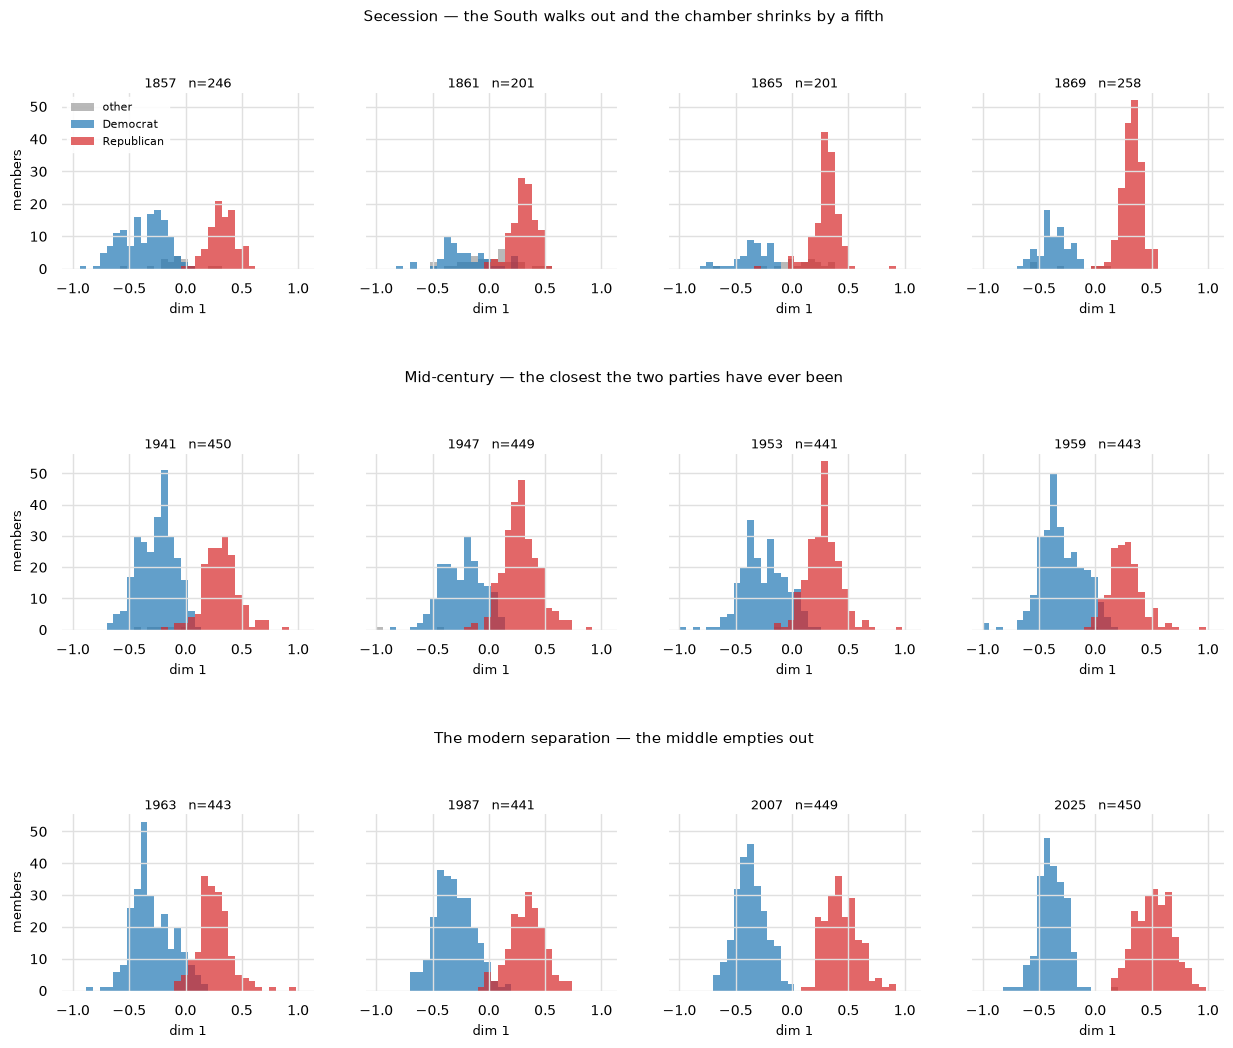

In [6]:
def parts(congress, chamber="House"):
    """Democrats, Republicans, and everyone else, for one chamber-Congress."""
    d = scores.get((congress, chamber, fetch.DEMOCRAT), [])
    r = scores.get((congress, chamber, fetch.REPUBLICAN), [])
    other = [v for (c, ch, party), vs in scores.items()
             if c == congress and ch == chamber
             and party not in (fetch.DEMOCRAT, fetch.REPUBLICAN) for v in vs]
    return d, r, other


ERAS = [
    ((35, 37, 39, 41), "Secession — the South walks out and the chamber shrinks by a fifth"),
    ((77, 80, 83, 86), "Mid-century — the closest the two parties have ever been"),
    ((88, 100, 110, 119), "The modern separation — the middle empties out"),
]
fig = pyplot.figure(figsize=(15, 10.5))
for n, (sub, (congresses, title)) in enumerate(zip(fig.subfigures(3, 1, hspace=0.10), ERAS)):
    axes = sub.subplots(1, 4, sharex=True, sharey=True)
    sub.subplots_adjust(top=0.74, bottom=0.20)
    for ax, congress in zip(axes, congresses):
        d, r, other = parts(congress)
        if other:
            ax.hist(other, bins=BINS, color="grey", alpha=0.55, label="other")
        ax.hist(d, bins=BINS, color="tab:blue", alpha=0.7, label="Democrat")
        ax.hist(r, bins=BINS, color="tab:red", alpha=0.7, label="Republican")
        ax.set_title(f"{1789 + (congress - 1) * 2}   n={len(d) + len(r) + len(other)}",
                     fontsize=9, pad=3)
        ax.set_xlabel("dim 1", fontsize=9)
    axes[0].set_ylabel("members", fontsize=9)
    if n == 0:
        axes[0].legend(fontsize=8, loc="upper left", framealpha=0.9)
    sub.suptitle(title, fontsize=11, y=0.99)


Three different shapes, and only the last is the one people picture.

**1857–1869.** The chamber drops from 246 members to 201 in 1861 and the
Democrats nearly vanish with it — 135 to 51 — because the Southern delegations
left. What is left is less a polarized Congress than a one-party one, and the
apparent gap is partly an artefact of who is missing rather than of anyone
moving.

**1941–1959.** Two mounds, but they touch, and the space between them is
populated. This is the conservative-coalition era; 1947 is the lowest median
gap in the entire record at 0.498, and in 1953 the parties are within four
seats of each other.

**1963–2025.** The overlap thins, then closes. By 2007 no member of either
party sits inside the other's range, and the mounds keep drifting apart after
that.

Third parties are worth watching too — a real share of the chamber through the
1860s, gone by the 1960s. The modern panels are two colours because there is
nothing else left to draw.

## Two reductions worth storing

A series needs one number per Congress, so something has to collapse those
~450 points. Two measures capture different halves of the same story, and
neither substitutes for the other.

**Distance between party medians** — how far apart the two blocs sit.
**Members inside the other party's range** — how many people are left in
between. The first can rise while the second is already zero, which is exactly
what has happened since 2007.

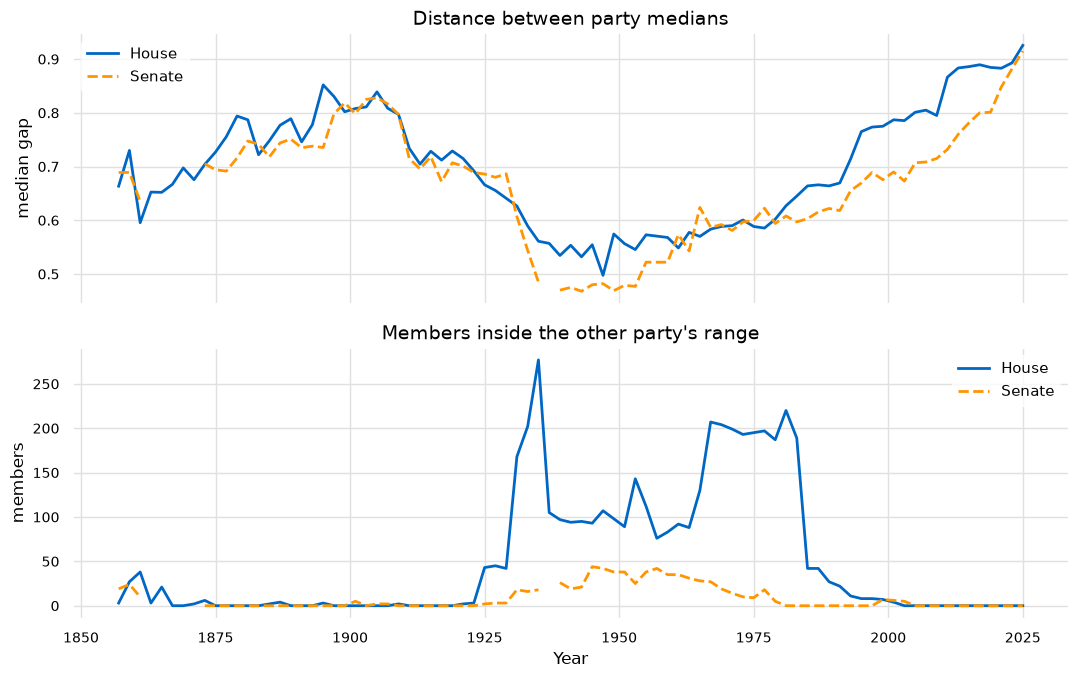

In [7]:
congresses = list(range(vs.TWO_PARTY_FROM + 1, 120))
years = [vs.congress_year(c) for c in congresses]

fig, (top, bottom) = pyplot.subplots(2, 1, figsize=(11, 7), sharex=True)
for chamber, style in (("House", "-"), ("Senate", "--")):
    top.plot(years, [vs.median_gap(scores, c, chamber) for c in congresses],
             style, lw=2, label=chamber)
    bottom.plot(years, [vs.moderate_bloc(scores, c, chamber) for c in congresses],
                style, lw=2, label=chamber)
top.set_ylabel("median gap"); top.set_title("Distance between party medians"); top.legend()
bottom.set_ylabel("members"); bottom.set_xlabel("Year")
bottom.set_title("Members inside the other party's range")
bottom.legend()
fig.tight_layout()

In [8]:
print("  year   House gap  bloc     Senate gap  bloc")
for c in (88, 100, 110, 119):
    print(f"  {vs.congress_year(c)}   "
          f"{vs.median_gap(scores, c, 'House'):.3f}     {vs.moderate_bloc(scores, c, 'House'):3.0f}       "
          f"{vs.median_gap(scores, c, 'Senate'):.3f}     {vs.moderate_bloc(scores, c, 'Senate'):3.0f}")


  year   House gap  bloc     Senate gap  bloc
  1963   0.578      88       0.543      31
  1987   0.666      42       0.615       0
  2007   0.805       0       0.709       0
  2025   0.925       0       0.915       0


## Centring it: aligned or polarized relative to the record

The gap is easier to read against its own long-run mean than in absolute
terms. Subtract the mean and the sign carries the meaning — **above the line
is more polarized than the historical average, below it is more aligned**.

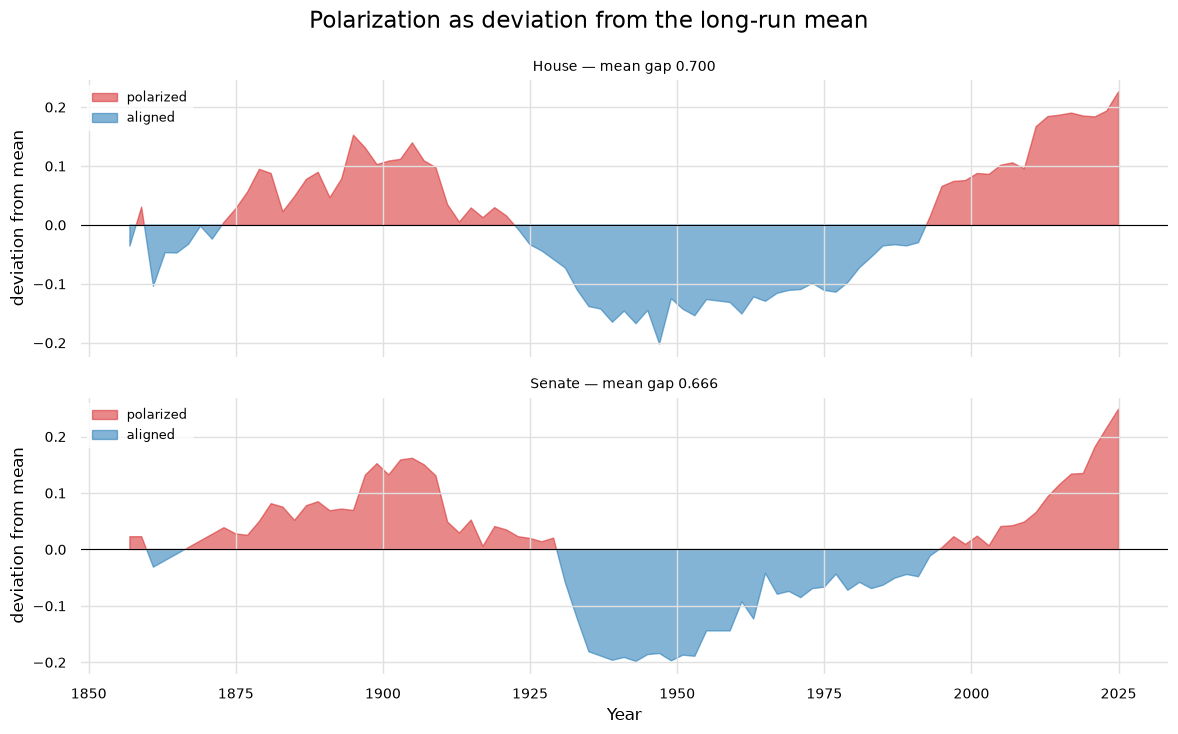

In [9]:
fig, axes = pyplot.subplots(2, 1, figsize=(12, 7.5), sharex=True)
summary = {}

for ax, chamber in zip(axes, fetch.CHAMBERS):
    points = [(vs.congress_year(c), vs.median_gap(scores, c, chamber))
              for c in range(vs.TWO_PARTY_FROM + 1, 120)]
    points = [(year, v) for year, v in points if v is not None]
    years = numpy.array([y for y, _ in points])
    values = numpy.array([v for _, v in points])
    deviation = values - values.mean()
    summary[chamber] = (years, values, deviation)

    ax.fill_between(years, deviation, 0, where=deviation >= 0, color="tab:red",
                    alpha=0.55, interpolate=True, label="polarized")
    ax.fill_between(years, deviation, 0, where=deviation <= 0, color="tab:blue",
                    alpha=0.55, interpolate=True, label="aligned")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("deviation from mean")
    ax.set_title(f"{chamber} — mean gap {values.mean():.3f}", fontsize=10)
    ax.legend(loc="upper left", fontsize=9)

axes[-1].set_xlabel("Year")
fig.suptitle("Polarization as deviation from the long-run mean")
fig.tight_layout()

In [10]:
for chamber, (years, values, deviation) in summary.items():
    low = int(numpy.argmin(deviation))
    high = int(numpy.argmax(deviation))
    print(f"  {chamber}: mean {values.mean():.3f}, sd {values.std():.3f}")
    print(f"    most aligned   {years[low]}  {deviation[low]:+.3f}")
    print(f"    most polarized {years[high]}  {deviation[high]:+.3f}")

    runs, current = [], []
    for year, d in zip(years, deviation):
        if d < 0:
            current.append(year)
        elif current:
            runs.append(current); current = []
    if current:
        runs.append(current)
    spans = [f"{r[0]}-{r[-1]} ({len(r)})" for r in runs if len(r) > 2]
    print(f"    sustained aligned spans: {', '.join(spans)}")


  House: mean 0.700, sd 0.108
    most aligned   1947  -0.202
    most polarized 2025  +0.226
    sustained aligned spans: 1861-1871 (6), 1923-1991 (35)
  Senate: mean 0.666, sd 0.107
    most aligned   1943  -0.198
    most polarized 2025  +0.249
    sustained aligned spans: 1931-1993 (31)


Three regimes, and the sign makes them obvious without reading values off an
axis.

**Gilded Age, roughly 1875–1925: polarized.** The House runs above its mean
for half a century.

**1923–1991: aligned.** Thirty-five consecutive Congresses below the mean in
the House, thirty-one in the Senate, with the trough at **1947 (−0.202)** —
the same period whose distribution panels show two mounds that touch. That is
a 68-year stretch, considerably wider than the 1940–1960 window it is usually
remembered as.

**1995 onward: polarized, and now beyond the Gilded Age.** 2025 is the
most polarized Congress in the record at **+0.226** in the House and **+0.249**
in the Senate — further above the mean than any point of the 1900s peak.

One caveat the plot cannot show. The brief aligned dip at **1861–1871** is not
cooperation; it is secession. With the Southern delegations gone the
Democratic party nearly vanishes from the House, and a median computed over 51
members is not measuring the same thing as one over 262. The distribution
panels above are the check on that.

The bloc hit **zero in the House in 2007** and has stayed there. The median gap
has kept climbing since — 0.805 to 0.925 — so the two measures are not
redundant: one says the parties keep moving apart, the other says there has
been nobody in the middle for two decades either way.

A first cut of stored series is therefore **4**: both measures × House and
Senate, congresses 35–119 (1857–2027). Note the coverage — Democrats and
Republicans do not both exist before the 34th Congress, so neither measure
reaches the 1789 start of the panel.

Anything about *specific votes* — bipartisan-vote fraction, party unity —
needs `rollcalls` and `votes`, which is 730 MB and a different exercise.
See `downloads.ipynb` for the size gate that keeps them out of the default
pull.

## Party size belongs in the measure

Everything above is Democrat-versus-Republican, so it starts in 1857 and says
nothing about the first third of the record. Two additions fix that, and the
second one is a correction to the first.

**How much does party predict position?** Take the two largest parties of
whatever Congress you are in — Adams and Jackson, Democrat and Whig, Democrat
and Republican — and divide the distance between their medians by the average
spread *within* them. Above 1, party tells you more about a member than their
own party's internal variation does. Below 1, it tells you less.

**Is there an opposition at all?** The Laakso–Taagepera effective number of
parties, `1 / Σ(share²)`. Two evenly matched parties give 2.0; one party
holding four fifths of the chamber gives about 1.4.

They are independent, and that is the point. A dominant party is not the same
thing as an agreeable one.

In [11]:
def two_largest(congress, chamber="House"):
    """The two biggest parties of that Congress, whatever they are called."""
    groups = sorted(((p, v) for (c, ch, p), v in scores.items()
                     if c == congress and ch == chamber),
                    key=lambda kv: -len(kv[1]))
    return groups[:2] if len(groups) >= 2 else None


def second_share(congress, chamber="House"):
    """The smaller of the two main parties, as a share of the chamber."""
    pair = two_largest(congress, chamber)
    if not pair:
        return None
    total = sum(len(v) for (c, ch, _), v in scores.items()
                if c == congress and ch == chamber)
    return len(pair[1][1]) / total


print("  year   parties  2nd share   predicts   reading")
for congress in (17, 19, 23, 39, 55, 80, 88, 110, 119):
    e = vs.effective_parties(scores, congress, "House")
    s = second_share(congress)
    r = vs.party_predicts_position(scores, congress, "House")
    gate = "" if s >= 0.40 else "   (rump — see below)"
    shown = f"{r:5.2f}" if r is not None else "    —"
    print(f"  {vs.congress_year(congress)}    {e:.2f}      {s:5.0%}      {shown}{gate}")

  year   parties  2nd share   predicts   reading
  1821    1.41        18%          —   (rump — see below)
  1825    2.00        50%       1.60
  1833    2.34        28%       2.30   (rump — see below)
  1865    1.93        22%          —   (rump — see below)
  1897    2.19        36%       7.47   (rump — see below)
  1947    1.98        43%       3.01
  1963    1.94        41%       3.50
  2007    1.99        46%       5.78
  2025    2.01        49%       6.71


### The representation gate

That ratio is confounded with the thing it sits beside. Sorting the record by
how big the second party is:

| second party | Congresses | mean ratio |
| --- | --- | --- |
| under 25% of the chamber | 9 | 3.24 |
| 25–40% | 44 | 4.17 |
| 40% or more | 66 | 5.01 |

Comparing a 163-member party's median against a 35-member remnant is not the
same measurement as comparing two 220-member parties — the remnant is a biased
survivor, not a small sample. It is **not** statistical noise: bootstrapping a
73-member party's median gives a standard deviation of 0.015, as tight as a
222-member one. The bias is compositional.

The confound is real but modest — second-party share explains 7.5% of the
ratio's variance — so the gate is set to exclude genuine one-party Congresses
rather than ordinary majorities. **25%** drops nine and keeps 110; a 60/40
chamber is a normal legislature and stays in. Setting it at 40% instead would
discard 53 Congresses including the entire Gilded Age peak, which is
overcorrecting for a 7.5% effect.

In [12]:
# vs.party_predicts_position applies the gate itself, returning None below
# vs.BALANCED -- so the counterfactual "what would this Congress have read?"
# has to be computed ungated. That is the only reason this exists: it is the
# number the gate suppresses, not a second copy of the measure.
def ungated_ratio(congress, chamber="House"):
    pair = two_largest(congress, chamber)
    if not pair or len(pair[1][1]) < 10:
        return None
    a, b = pair[0][1], pair[1][1]
    within = (statistics.pstdev(a) * len(a) + statistics.pstdev(b) * len(b)) / (len(a) + len(b))
    return abs(statistics.median(a) - statistics.median(b)) / within if within else None


print(f"BALANCED = {vs.BALANCED}\n")

raw = [(vs.congress_year(c), ungated_ratio(c), second_share(c)) for c in range(1, 120)]
raw = [(y, r, s) for y, r, s in raw if r is not None and s is not None]

qualified = [(y, r, s) for y, r, s in raw if s >= vs.BALANCED]
excluded  = [(y, r, s) for y, r, s in raw if s < vs.BALANCED]

print(f"  {len(qualified)} balanced Congresses, {qualified[0][0]}-{qualified[-1][0]}\n")
for label, rows_ in (("most unified", sorted(qualified, key=lambda t: t[1])[:5]),
                     ("most divided", sorted(qualified, key=lambda t: -t[1])[:5])):
    print(f"  {label}: " + ", ".join(f"{y} {r:.2f}" for y, r, _ in rows_))

print(f"\n  excluded as rump comparisons ({len(excluded)}):")
for y, r, s in excluded:
    print(f"    {y}  second party {s:4.0%}  ratio would read {r:.2f}")

# the gate is the module's, so the two must agree on what survives it
assert all(vs.party_predicts_position(scores, c, "House") is None
           for c in range(1, 120) if (second_share(c) or 1) < vs.BALANCED)

BALANCED = 0.25

  110 balanced Congresses, 1789-2025

  most unified: 1823 0.87, 1825 1.60, 1835 1.72, 1789 2.01, 1837 2.03
  most divided: 1905 9.27, 1907 8.78, 1881 8.17, 1879 8.11, 1909 8.05

  excluded as rump comparisons (9):
    1805  second party  19%  ratio would read 4.07
    1807  second party  18%  ratio would read 3.74
    1817  second party  21%  ratio would read 1.32
    1819  second party  14%  ratio would read 0.83
    1821  second party  18%  ratio would read 0.65
    1865  second party  22%  ratio would read 5.02
    1867  second party  21%  ratio would read 6.24
    1935  second party  24%  ratio would read 3.57
    1937  second party  21%  ratio would read 3.69


Read against the gated record, the extremes are **1905, 1907 and 1881** — the
Gilded Age — against **1823, 1825 and 1835**. The founding and Jacksonian
Congresses are the unified end; the turn of the twentieth century is the
divided one, with the present climbing back toward it.

That also disposes of a tempting parallel. 1825 and 2025 have the same seat
arithmetic — a dead-even split — and opposite ideological structure: 1.60
against 6.71. The modern condition is not "a close election"; it is a close
election between two blocs that no longer overlap, and only the Gilded Age has
looked like that before.

The excluded Congresses would have ranked 1819 and 1821 as the most unified
ever. They are dropped because they are not the same measurement, and because
a supermajority is not evidence of agreement: the dominant party of 1821 has
the **highest internal spread of any party in 119 Congresses** (0.396 against a
mean of 0.163). It was a big tent absorbing the Federalist collapse, not a
consensus. Compare 1805 and 1807, which had the same 82% dominance with an
ordinary spread of 0.18 — dominance and coherence are separable.

### Two limits worth stating plainly

**This measures Congress, not the country.** Seat share is not vote share, and
first-past-the-post amplifies margins, so none of it settles whether the
electorate was more or less divided — only whether its legislature was.

**The axis is a common scale, not a common subject.** `dim1` is estimated so
that Congresses can be compared, but what members were *dividing over* changes
completely: the Bank, tariffs and internal improvements in the 1830s; silver
and trusts in the 1890s; the New Deal settlement mid-century; and today
something else again. A ratio of 1.60 in 1825 and 6.71 in 2025 says the
legislature was more sharply sorted, not that the two eras were arguing about
comparable things. Treat the number as a measure of *structure* and never of
*content* — for content you need the roll calls themselves, which is
`HSall_rollcalls.csv` and its `vote_desc` field, held back by the size gate in
`downloads.ipynb`.